# Quantum Correlations in the Prisoner's Dilemma

Three acts:

1. **Classical PD in quantum language** — product states only; recover the classical Nash equilibrium
2. **EWL: what entanglement changes** — why allowing quantum strategies escapes the trap
3. **The Toner-Bacon gap** — how much classical communication is needed to fake the quantum correlations

Dependencies: `numpy`, `matplotlib` only.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ── PD payoff values (standard ordering T > R > P > S) ──────────────────────
T, R, P, S = 5, 3, 1, 0

# ── Payoff operators (diagonal in {|CC>, |CD>, |DC>, |DD>} basis) ────────────
PA = np.diag([R, S, T, P]).astype(complex)   # Alice's payoff
PB = np.diag([R, T, S, P]).astype(complex)   # Bob's payoff

## Act 1 — Classical PD in quantum language

A classical mixed strategy is just a cooperation probability $p$. Write Alice's state as:
$$|\psi_A\rangle = \sqrt{p}\,|C\rangle + \sqrt{1-p}\,|D\rangle$$
The amplitudes are real and non-negative — no superposition in the quantum sense, just probability weights packed into a vector. Bob's state $|\psi_B\rangle$ is defined the same way with his own $q$.

The two-player state is the product:
$$|\psi\rangle = |\psi_A\rangle \otimes |\psi_B\rangle$$

The payoff operator for Alice is diagonal in the two-player basis $\{|CC\rangle, |CD\rangle, |DC\rangle, |DD\rangle\}$:
$$\hat{P}_A = \mathrm{diag}(R,\, S,\, T,\, P) = \mathrm{diag}(3,\, 0,\, 5,\, 1)$$

The expected payoff is the sandwich:
$$\langle \hat{P}_A \rangle = \langle\psi|\hat{P}_A|\psi\rangle$$

Because $\hat{P}_A$ is diagonal, only the squared amplitudes (i.e.\ the probabilities) appear — any phase between $|C\rangle$ and $|D\rangle$ drops out. The result is exactly the classical weighted sum $pq\,R + p(1{-}q)\,S + (1{-}p)q\,T + (1{-}p)(1{-}q)\,P$ — no new physics yet, just a notation that carries forward cleanly to Act 2.

In [11]:
def state(p):
    """Classical strategy as amplitude vector: |ψ⟩ = √p|C⟩ + √(1-p)|D⟩"""
    return np.array([np.sqrt(p), np.sqrt(1 - p)], dtype=complex)

def expected_payoff(psi_A, psi_B, payoff_op):
    psi = np.kron(psi_A, psi_B)
    return float(np.real(psi.conj() @ payoff_op @ psi))

# Sanity check: recover the 2×2 payoff matrix
print("Alice's payoff for pure strategy pairs:")
for sa, la in [(1.0, 'C'), (0.0, 'D')]:
    for sb, lb in [(1.0, 'C'), (0.0, 'D')]:
        pi = expected_payoff(state(sa), state(sb), PA)
        print(f"  ({la},{lb}): {pi:.0f}")

Alice's payoff for pure strategy pairs:
  (C,C): 3
  (C,D): 0
  (D,C): 5
  (D,D): 1


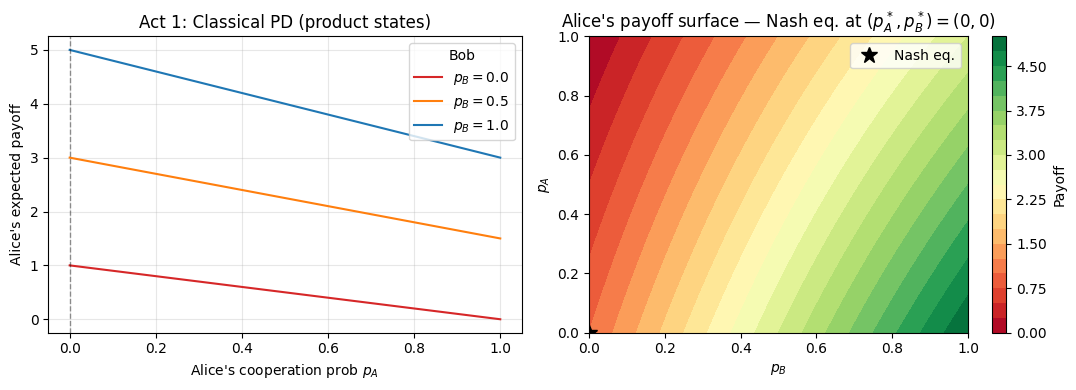

Nash eq. payoff (D,D): Alice=1, Bob=1
Pareto opt. (C,C):     Alice=3, Bob=3


In [12]:
ps = np.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for p_B, color in [(0.0, 'C3'), (0.5, 'C1'), (1.0, 'C0')]:
    axes[0].plot(ps, [expected_payoff(state(p), state(p_B), PA) for p in ps],
                 color=color, label=f'$p_B={p_B}$')

axes[0].axvline(0, color='k', lw=1, ls='--', alpha=0.4)
axes[0].set_xlabel("Alice's cooperation prob $p_A$")
axes[0].set_ylabel("Alice's expected payoff")
axes[0].set_title("Act 1: Classical PD (product states)")
axes[0].legend(title='Bob')
axes[0].grid(alpha=0.3)

# Nash equilibrium surface
PA_grid = np.array([[expected_payoff(state(pA), state(pB), PA)
                     for pB in ps] for pA in ps])
im = axes[1].contourf(ps, ps, PA_grid, levels=20, cmap='RdYlGn')
axes[1].set_xlabel("$p_B$")
axes[1].set_ylabel("$p_A$")
axes[1].set_title("Alice's payoff surface — Nash eq. at $(p_A^*,p_B^*)=(0,0)$")
plt.colorbar(im, ax=axes[1], label='Payoff')
axes[1].plot(0, 0, 'k*', ms=12, label='Nash eq.')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Nash eq. payoff (D,D): Alice={expected_payoff(state(0), state(0), PA):.0f},",
      f"Bob={expected_payoff(state(0), state(0), PB):.0f}")
print(f"Pareto opt. (C,C):     Alice={expected_payoff(state(1), state(1), PA):.0f},",
      f"Bob={expected_payoff(state(1), state(1), PB):.0f}")

**Takeaway:** For every fixed $p_B$, Alice's payoff is highest at $p_A = 0$ (defect). Defection is a dominant strategy — the classical trap holds regardless of Bob's choice.

---

## Act 2 — EWL: a larger strategy space

In the EWL quantum game (Eisert, Wilkens & Lewenstein 1999) the full protocol is:
$$|\psi_f\rangle = J^\dagger\,(U_A \otimes U_B)\,J\,|CC\rangle$$

Three actors, two of which belong to the referee:

- $J$ **(referee, before players):** entangles the neutral starting state into the shared quantum resource $|\Phi\rangle = J|CC\rangle = \tfrac{1}{\sqrt{2}}(|CC\rangle + i|DD\rangle)$.
- $U_A \otimes U_B$ **(players):** each player applies a local unitary to their own qubit — independently, without touching the other's qubit.
- $J^\dagger = J^{-1}$ **(referee, after players):** not a measurement device — simply the inverse of $J$. It returns the state to the classical outcome basis $\{|CC\rangle,|CD\rangle,|DC\rangle,|DD\rangle\}$.

Payoff is then the same sandwich as Act 1: $\langle\psi_f|\hat{P}_A|\psi_f\rangle$. The formula is identical; only the state changes.

$J$ and $J^\dagger$ together bracket the players' moves. Each player's strategy is a 2×2 unitary. Three strategies span the relevant space:

| Strategy | Matrix | Action on single qubit |
|---|---|---|
| $C = I$ | $\begin{pmatrix}1&0\\0&1\end{pmatrix}$ | identity: $\|C\rangle\to\|C\rangle$, $\|D\rangle\to\|D\rangle$ |
| $D = i\sigma_x$ | $\begin{pmatrix}0&i\\i&0\end{pmatrix}$ | bit-flip (quantum NOT): $\|C\rangle\to i\|D\rangle$, $\|D\rangle\to i\|C\rangle$ |
| $\hat{Q} = i\sigma_z$ | $\begin{pmatrix}i&0\\0&-i\end{pmatrix}$ | phase-flip: $\|C\rangle\to i\|C\rangle$, $\|D\rangle\to -i\|D\rangle$ |

$C$ and $D$ are real rotations — $\sigma_x$ is a real matrix and classical probabilities suffice to describe their effect. $\hat{Q} = i\sigma_z$ is purely a phase operation: it leaves the single-qubit measurement probabilities unchanged, but after the $J^\dagger\ldots J$ bracket the relative phase between $|C\rangle$ and $|D\rangle$ shifts the outcome. That is what makes $\hat{Q}$ a genuinely quantum strategy with no classical analogue.

In [ ]:
# Entangling operator J at γ = π/2 (referee prepares entangled resource)
J = np.array([
    [1,  0,  0, 1j],
    [0,  1, 1j,  0],
    [0, 1j,  1,  0],
    [1j, 0,  0,  1],
], dtype=complex) / np.sqrt(2)

J_dag = J.conj().T          # J† = J⁻¹: referee un-entangles after players act

CC = np.array([1, 0, 0, 0], dtype=complex)   # |CC⟩ — classical starting point
psi_ent = J @ CC                              # J|CC⟩ = (|CC⟩ + i|DD⟩)/√2

# Pauli matrices (single-qubit building blocks)
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_z = np.diag([1, -1]).astype(complex)

# Strategies: local unitaries each player applies to their own qubit
C_strat = np.eye(2, dtype=complex)   # Cooperate: identity
D_strat = 1j * sigma_x               # Defect:    i·σ_x, swaps |C⟩ ↔ |D⟩
Q_strat = 1j * sigma_z               # Quantum:   i·σ_z, phase-flips |D⟩

def ewl_payoffs(UA, UB):
    """Payoff ⟨ψ_f|P̂|ψ_f⟩ with |ψ_f⟩ = J†(UA⊗UB)J|CC⟩."""
    psi_f = J_dag @ np.kron(UA, UB) @ psi_ent
    piA = float(np.real(psi_f.conj() @ PA @ psi_f))
    piB = float(np.real(psi_f.conj() @ PB @ psi_f))
    return piA, piB

strats = {'C': C_strat, 'D': D_strat, 'Q̂': Q_strat}

# 3×3 payoff table: (Alice payoff, Bob payoff)
print("Payoff table (Alice, Bob) at maximum entanglement:")
print(f"{'':14s}" + "  ".join(f"Bob:{lb:3s}" for lb in strats))
for la, UA in strats.items():
    row = f"Alice:{la:5s} |"
    for lb, UB in strats.items():
        piA, piB = ewl_payoffs(UA, UB)
        row += f"  ({piA:.0f},{piB:.0f})  "
    print(row)

In [14]:
# Verify: do classical strategies land on classical basis states?
print("Final-state probabilities  P(outcome) = |⟨outcome|ψ_f⟩|²")
print(f"{'':12s}  {'P(CC)':>6}  {'P(CD)':>6}  {'P(DC)':>6}  {'P(DD)':>6}   payoff_A")
for la, UA in strats.items():
    for lb, UB in strats.items():
        psi_f = J_dag @ np.kron(UA, UB) @ psi_ent
        probs = np.abs(psi_f) ** 2
        piA = float(np.real(psi_f.conj() @ PA @ psi_f))
        prob_str = "  ".join(f"{p:6.2f}" for p in probs)
        print(f"  ({la},{lb}):  {prob_str}   {piA:.0f}")

Final-state probabilities  P(outcome) = |⟨outcome|ψ_f⟩|²
               P(CC)   P(CD)   P(DC)   P(DD)   payoff_A
  (C,C):    1.00    0.00    0.00    0.00   3
  (C,D):    0.00    1.00    0.00    0.00   0
  (C,Q̂):    0.00    0.00    0.00    1.00   1
  (D,C):    0.00    0.00    1.00    0.00   5
  (D,D):    0.00    0.00    0.00    1.00   1
  (D,Q̂):    0.00    1.00    0.00    0.00   0
  (Q̂,C):    0.00    0.00    0.00    1.00   1
  (Q̂,D):    0.00    0.00    1.00    0.00   5
  (Q̂,Q̂):    1.00    0.00    0.00    0.00   3


For every classical strategy pair the final state is a single basis state — certainty, not superposition. The $J^\dagger\ldots J$ bracket "un-entangles" classical strategies back to deterministic outcomes, so the payoff sandwich $\langle\psi_f|\hat{P}_A|\psi_f\rangle$ simply reads off the diagonal entry for that outcome. Entanglement adds nothing for players who stay classical.

$\hat{Q}$ against $D$ is the key: $(\hat{Q}, D)$ also lands on $|DC\rangle$ with certainty — Alice gets $T=5$ against a defector without herself defecting. That is the new degree of freedom. Because $\hat{Q}$ beats $D$, defection is no longer dominant, and the classical trap breaks.

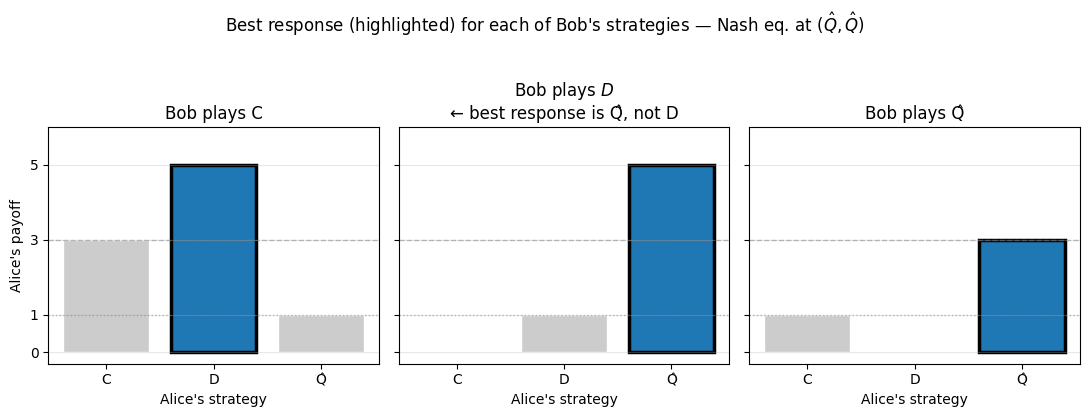

Nash equilibrium check:
  Nash eq: (Q̂,Q̂) → payoff (3,3)


In [15]:
strat_labels = list(strats.keys())

fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True)

for ax, (bob_name, UB) in zip(axes, strats.items()):
    alice_payoffs = [ewl_payoffs(UA, UB)[0] for UA in strats.values()]
    best_idx = int(np.argmax(alice_payoffs))
    colors = ['#cccccc'] * 3
    colors[best_idx] = 'C0'
    bars = ax.bar(strat_labels, alice_payoffs, color=colors, edgecolor='white')
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)
    ax.axhline(R, color='gray', lw=1, ls='--', alpha=0.5)
    ax.axhline(P, color='gray', lw=1, ls=':', alpha=0.5)
    ax.set_title(f"Bob plays {bob_name}")
    ax.set_xlabel("Alice's strategy")
    ax.set_ylim(-0.3, 6)
    ax.set_yticks([0, 1, 3, 5])
    ax.grid(alpha=0.3, axis='y')

axes[0].set_ylabel("Alice's payoff")
axes[1].set_title(r"Bob plays $D$" + "\n← best response is Q̂, not D")
plt.suptitle(r"Best response (highlighted) for each of Bob's strategies — Nash eq. at $(\hat{Q},\hat{Q})$",
             y=1.03)
plt.tight_layout()
plt.show()

print("Nash equilibrium check:")
for la, UA in strats.items():
    for lb, UB in strats.items():
        alice_best = strat_labels[int(np.argmax([ewl_payoffs(UA2, UB)[0] for UA2 in strats.values()]))]
        bob_best   = strat_labels[int(np.argmax([ewl_payoffs(UA, UB2)[1] for UB2 in strats.values()]))]
        is_nash = (alice_best == la and bob_best == lb)
        if is_nash:
            piA, piB = ewl_payoffs(UA, UB)
            print(f"  Nash eq: ({la},{lb}) → payoff ({piA:.0f},{piB:.0f})")

**Takeaway:** At maximum entanglement the payoff table changes structurally. Classical strategies C and D still give classical payoffs — entanglement alone does nothing. But $\hat{Q}$ is a new strategy that becomes dominant against $D$ (Alice gets $T=5$ instead of $P=1$), so $(D,D)$ is no longer a Nash equilibrium. The unique Nash equilibrium in the strategy set $\{C, D, \hat{Q}\}$ is $(\hat{Q},\hat{Q})$ with Pareto-optimal payoff $(R,R)=(3,3)$.

$\hat{Q}$ is not a probability — it is a phase rotation of Alice's qubit ($i$ on the $|C\rangle$ component, $-i$ on the $|D\rangle$ component). It has no classical counterpart; it only exists in the enlarged strategy space that entanglement makes available.

The question Act 3 asks: can a classical resource — a single communicated bit — produce the same correlations?

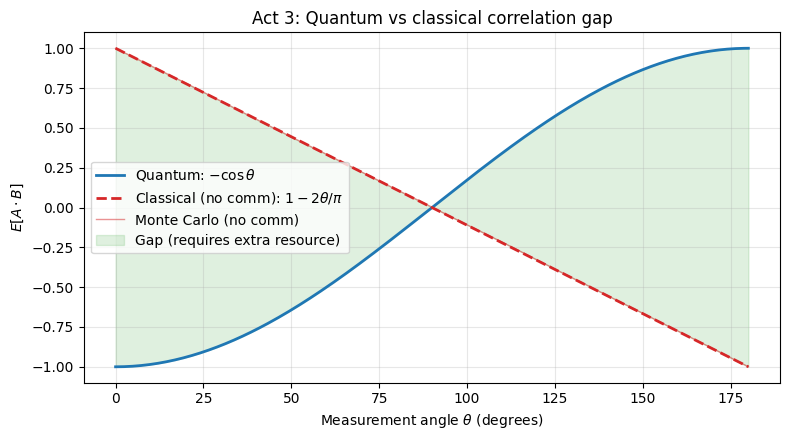

In [16]:
N = 200_000
# Shared random unit vectors on S²
lam = rng.standard_normal((N, 3))
lam /= np.linalg.norm(lam, axis=1, keepdims=True)

thetas = np.linspace(0, np.pi, 300)

# Fix Alice's direction: a = z-axis
a = np.array([0.0, 0.0, 1.0])
A = np.sign(lam @ a)   # Alice's outcomes for all samples

corr_classical = np.empty(len(thetas))
for i, th in enumerate(thetas):
    b = np.array([np.sin(th), 0.0, np.cos(th)])   # Bob's direction at angle θ from a
    B = np.sign(lam @ b)
    corr_classical[i] = np.mean(A * B)

corr_quantum    = -np.cos(thetas)
corr_linear     =  1 - 2 * thetas / np.pi

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.degrees(thetas), corr_quantum,  'C0',   lw=2,  label=r'Quantum: $-\cos\theta$')
ax.plot(np.degrees(thetas), corr_linear,   'C3--', lw=2,  label=r'Classical (no comm): $1-2\theta/\pi$')
ax.plot(np.degrees(thetas), corr_classical,'C3',   lw=1, alpha=0.5, label='Monte Carlo (no comm)')
ax.fill_between(np.degrees(thetas), corr_classical, corr_quantum,
                alpha=0.15, color='C2', label='Gap (requires extra resource)')
ax.set_xlabel(r'Measurement angle $\theta$ (degrees)')
ax.set_ylabel(r'$E[A \cdot B]$')
ax.set_title('Act 3: Quantum vs classical correlation gap')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### CHSH inequality

The **CHSH inequality** (Clauser-Horne-Shimony-Holt) formalises the gap:
$$S = |E[AB] + E[AB'] + E[A'B] - E[A'B']| \leq 2 \quad \text{(any local hidden variable model)}$$

Quantum mechanics can reach $S = 2\sqrt{2} \approx 2.828$. The optimal settings:
$\mathbf{a}=0°$, $\mathbf{a}'=90°$, $\mathbf{b}=45°$, $\mathbf{b}'=-45°$.

In [17]:
def chsh(corr_fn):
    """CHSH value for a given correlation function corr_fn(theta_deg)."""
    # Optimal settings: a=0°, a'=90°, b=45°, b'=-45° (equiv. 315°, angle from a is 45°)
    # Angles between directions:
    #   (a,b)=45°, (a,b')=45°, (a',b)=45°, (a',b')=135°
    e_ab  = corr_fn(45)
    e_ab_ = corr_fn(45)
    e_a_b = corr_fn(45)
    e_a_b_= corr_fn(135)
    return abs(e_ab + e_ab_ + e_a_b - e_a_b_)

def quantum_corr(theta_deg):
    return -np.cos(np.radians(theta_deg))

def classical_corr(theta_deg):
    return 1 - 2 * np.radians(theta_deg) / np.pi

S_q  = chsh(quantum_corr)
S_cl = chsh(classical_corr)

print(f"CHSH value — quantum:            {S_q:.4f}  (= 2√2 = {2*np.sqrt(2):.4f})")
print(f"CHSH value — classical (no comm):{S_cl:.4f}  (= 2, exactly at Bell bound)")
print(f"Gap:                              {S_q - S_cl:.4f}")

# Monte Carlo verification
def chsh_mc(lam_samples, a_deg, a2_deg, b_deg, b2_deg):
    def d(deg): return np.array([np.sin(np.radians(deg)), 0, np.cos(np.radians(deg))])
    A  = np.sign(lam_samples @ d(a_deg))
    A2 = np.sign(lam_samples @ d(a2_deg))
    B  = np.sign(lam_samples @ d(b_deg))
    B2 = np.sign(lam_samples @ d(b2_deg))
    return abs(np.mean(A*B) + np.mean(A*B2) + np.mean(A2*B) - np.mean(A2*B2))

S_mc = chsh_mc(lam, 0, 90, 45, -45)
print(f"CHSH value — Monte Carlo (no comm):{S_mc:.4f}")

CHSH value — quantum:            2.8284  (= 2√2 = 2.8284)
CHSH value — classical (no comm):2.0000  (= 2, exactly at Bell bound)
Gap:                              0.8284
CHSH value — Monte Carlo (no comm):2.0000


### The Toner-Bacon result (2003)

> **Theorem** (Toner & Bacon, PRL 91, 187904, 2003):  
> *Exactly **1 classical bit** from Alice to Bob, combined with unlimited shared randomness, is sufficient to simulate the quantum singlet correlations $E[AB]=-\cos\theta$ for all projective measurements.*

Together with Bell's theorem (0 bits insufficient), this places quantum entanglement at a precise point in the communication-complexity hierarchy:

| Resource | Achievable correlation | CHSH |
|---|---|---|
| 0 bits + shared randomness | $1 - 2\theta/\pi$ | $\leq 2$ |
| **1 bit** + shared randomness | $-\cos\theta$ (exact) | $2\sqrt{2}$ |
| Quantum entanglement | $-\cos\theta$ (exact) | $2\sqrt{2}$ |

The 1 bit is not redundant — Bell's theorem proves it is necessary.

### Why the bit helps: conditional structure

Alice sends $c = \mathrm{sign}(\mathbf{a}\cdot\lambda)$ (1 bit).  
Given $c=+1$, Bob knows $\lambda$ is in the hemisphere $\{\mathbf{a}\cdot\lambda > 0\}$.  
This changes the *conditional* distribution of $\mathrm{sign}(\mathbf{b}\cdot\lambda)$, creating a geometric asymmetry that depends on the angle between $\mathbf{a}$ and $\mathbf{b}$.

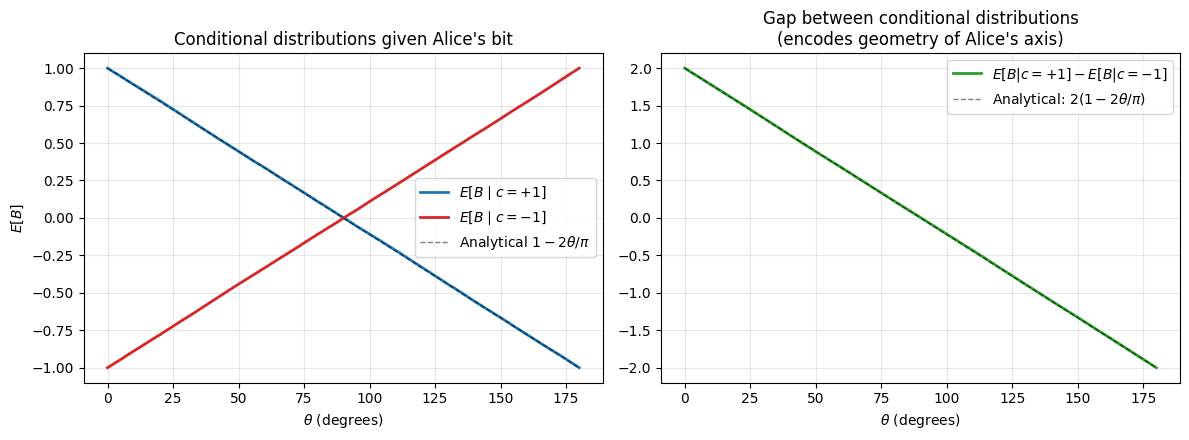

The gap E[B|c=+1] - E[B|c=-1] is non-zero for all θ ∈ (0°, 180°).
This is the geometric information about Alice's axis that the 1 bit encodes.
Toner-Bacon (2003) constructs a decision rule for Bob that uses this to achieve -cosθ.


In [18]:
# Conditional correlation structure: E[sign(b·λ) | c = ±1]
# Analytical: E[sign(b·λ) | sign(a·λ)=+1] = 1 - 2θ/π  (same linear form)
#             E[sign(b·λ) | sign(a·λ)=-1] = -(1 - 2θ/π)
# The bit c breaks the symmetry — the two conditional distributions differ.

thetas_deg = np.linspace(0, 180, 300)
thetas_rad = np.radians(thetas_deg)

# Monte Carlo: compute conditional means
cond_pos = np.empty(len(thetas_deg))  # E[sign(b·λ) | c=+1]
cond_neg = np.empty(len(thetas_deg))  # E[sign(b·λ) | c=-1]

c_alice = np.sign(lam @ a)  # Alice's bit for all samples
mask_pos = c_alice > 0
mask_neg = c_alice < 0

for i, th in enumerate(thetas_rad):
    b = np.array([np.sin(th), 0.0, np.cos(th)])
    B = np.sign(lam @ b)
    cond_pos[i] = np.mean(B[mask_pos])
    cond_neg[i] = np.mean(B[mask_neg])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: conditional distributions
axes[0].plot(thetas_deg, cond_pos,  'C0', lw=2, label=r'$E[B\mid c=+1]$')
axes[0].plot(thetas_deg, cond_neg,  'C3', lw=2, label=r'$E[B\mid c=-1]$')
axes[0].plot(thetas_deg, 1 - 2*thetas_rad/np.pi, 'k--', lw=1,
             alpha=0.5, label=r'Analytical $1-2\theta/\pi$')
axes[0].set_xlabel(r'$\theta$ (degrees)')
axes[0].set_ylabel(r"$E[B]$")
axes[0].set_title("Conditional distributions given Alice's bit")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: gap between conditional distributions
gap = cond_pos - cond_neg
axes[1].plot(thetas_deg, gap, 'C2', lw=2, label=r'$E[B|c=+1] - E[B|c=-1]$')
axes[1].plot(thetas_deg, 2*(1 - 2*thetas_rad/np.pi), 'k--', lw=1, alpha=0.5,
             label=r'Analytical: $2(1-2\theta/\pi)$')
axes[1].set_xlabel(r'$\theta$ (degrees)')
axes[1].set_title("Gap between conditional distributions\n(encodes geometry of Alice's axis)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("The gap E[B|c=+1] - E[B|c=-1] is non-zero for all θ ∈ (0°, 180°).")
print("This is the geometric information about Alice's axis that the 1 bit encodes.")
print("Toner-Bacon (2003) constructs a decision rule for Bob that uses this to achieve -cosθ.")

### Connection to the EWL game

The $(\hat{Q},\hat{Q})$ Nash equilibrium in the EWL game requires a shared entangled channel between the players. Toner-Bacon shows this is equivalent to:

- **Shared common knowledge** — the hidden variable $\lambda$ (both players' background understanding of the situation)
- **One private message** $c$ from Alice to Bob

This is not a metaphor — it is a mathematical equivalence in communication complexity.

A successful back-channel in diplomacy has exactly this structure: shared context (both sides understand the payoffs and the stakes) plus one private communicated offer (the Dobrynin channel in the Cuban Missile Crisis; OPEC's shared oil-price signal; the Paris Agreement's ratchet mechanism).

The quantum formalism is the right mathematical language to reason about what correlated pre-commitment *structurally requires* — whether or not the players are physically sharing qubits.